In [ ]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Data Analysis

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AI/Brain Tumor Classifcation"

folders = [f for f in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, f))]

print("Folders in dataset:", folders)
print("Total number of folders:", len(folders))

Folders in dataset: ['train', 'test']
Total number of folders: 2


In [ ]:
total_files = 0

for root, dirs, files in os.walk(dataset_path):
    total_files += len(files)

print("Total files in dataset:", total_files)

Total files in dataset: 3096


Class Distribution

Train

In [ ]:
train_path = "/content/drive/MyDrive/AI/Brain Tumor Classifcation/train"

for category in os.listdir(train_path):
    print(category, ":", len(os.listdir(os.path.join(train_path, category))))

normal : 350
pituitary_tumor : 675
glioma_tumor : 720
meningioma_tumor : 730


Test

In [ ]:
test_path = "/content/drive/MyDrive/AI/Brain Tumor Classifcation/test"

for category in os.listdir(test_path):
    print(category, ":", len(os.listdir(os.path.join(test_path, category))))

pituitary_tumor : 169
meningioma_tumor : 183
normal : 88
glioma_tumor : 181


Plot for class distribution


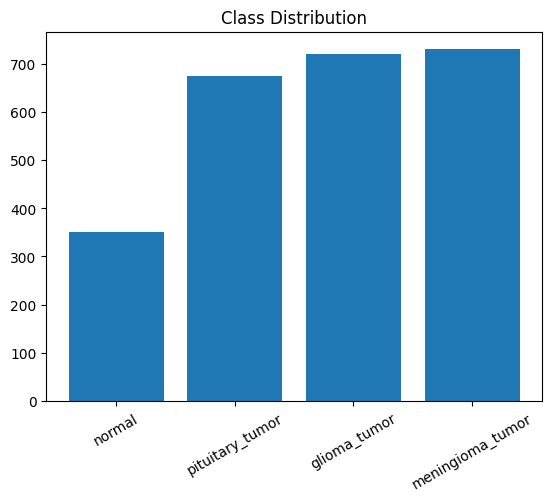

In [ ]:
import matplotlib.pyplot as plt

categories = os.listdir(train_path)
counts = []

for category in categories:
    counts.append(len(os.listdir(os.path.join(train_path, category))))

plt.bar(categories, counts)
plt.xticks(rotation=30)
plt.title("Class Distribution")
plt.show()

Sample Images from each class


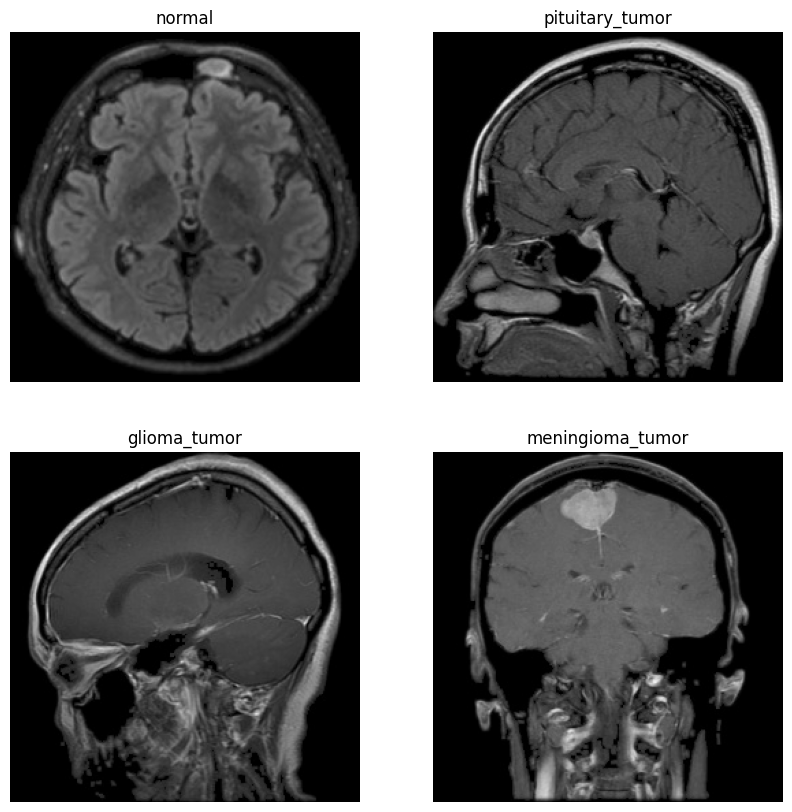

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, category in enumerate(categories):
    path = os.path.join(train_path, category)

    files = os.listdir(path)

    for file in files:
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(2,2,i+1)
            plt.imshow(img)
            plt.title(category)
            plt.axis('off')
            break   # stop after first valid image

plt.show()

Image size check

In [ ]:
for category in categories:
    path = os.path.join(train_path, category)

    files = os.listdir(path)

    for file in files:
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)

        if img is not None:
            print(category, img.shape)
            break   # stop after first valid image

normal (256, 256, 3)
pituitary_tumor (256, 256, 3)
glioma_tumor (256, 256, 3)
meningioma_tumor (256, 256, 3)


Check corroupted files

In [ ]:
import os
from PIL import Image

corrupted_images = []

for class_name in categories:
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        for img in images:
            img_path = os.path.join(class_path, img)

            try:
                with Image.open(img_path) as image:
                    image.verify()

            except Exception:
                corrupted_images.append(img_path)

print("Corrupted Images:", len(corrupted_images))

Corrupted Images: 28


Remove corroupted images

In [ ]:
if corrupted_images:
    print("Removing corrupted images...")

    for img_path in corrupted_images:
        if os.path.exists(img_path):
            os.remove(img_path)

    print("Removed:", len(corrupted_images))
else:
    print("No corrupted images found.")

Removing corrupted images...
Removed: 28


Class count after cleaning

In [ ]:
class_counts = {}

for class_name in categories:
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)

print(class_counts)

{'normal': 343, 'pituitary_tumor': 668, 'glioma_tumor': 713, 'meningioma_tumor': 723}


PREPROCESSING

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

LOAD DATA

In [ ]:
from tensorflow import keras
image_size = (224, 224)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 2447 files belonging to 4 classes.
Using 1958 files for training.


In [ ]:
val_ds = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 2447 files belonging to 4 classes.
Using 489 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False # Important for consistent label extraction
)

Found 621 files belonging to 4 classes.


BASELINE CNN


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Conv Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Conv Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Conv Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# OUTPUT LAYER (
model.add(Dense(4, activation='softmax'))  # 4 classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,476 (42.64 MB)

 Trainable params: 11,177,476 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

COMPILE

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAIN

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - accuracy: 0.4270 - loss: 14.2371 - val_accuracy: 0.5746 - val_loss: 0.9643
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.6895 - loss: 0.7575 - val_accuracy: 0.6585 - val_loss: 0.8930
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.8115 - loss: 0.5068 - val_accuracy: 0.6524 - val_loss: 0.8672
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.8851 - loss: 0.3187 - val_accuracy: 0.6810 - val_loss: 1.0327
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9321 - loss: 0.1969 - val_accuracy: 0.7301 - val_loss: 0.9189
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9627 - loss: 0.1113 - val_accuracy: 0.7117 - val_loss: 1.2342
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9515 - loss: 0.1294 - val_accuracy: 0.7239 - val_loss: 1.0811
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.9714 - loss: 0.0891 - val_accurac

PLOT GRAPH

Accuracy

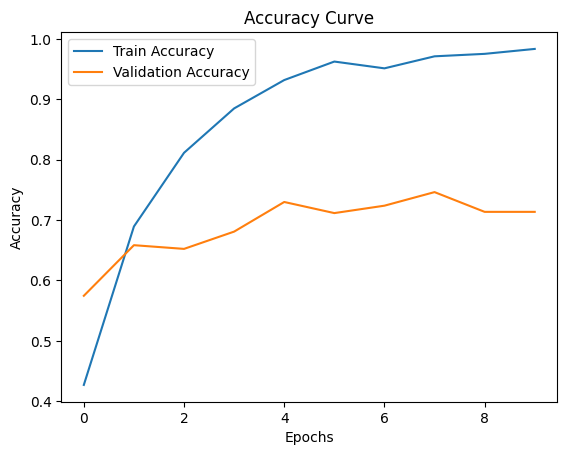

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

Loss

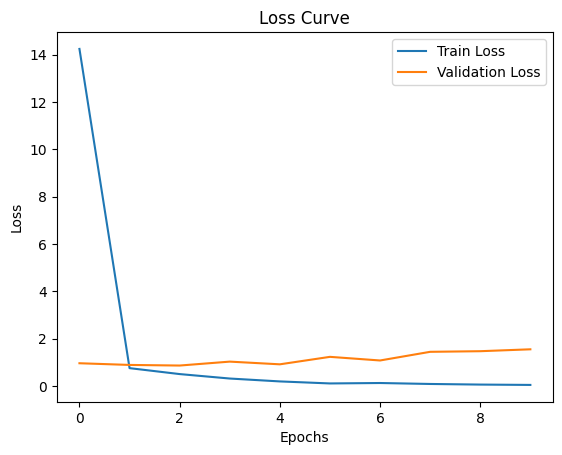

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

Evaluate Model on Test Data

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf

# Predict on test data
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
class_labels = test_ds.class_names

20/20 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step


In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.7375 - loss: 1.8560
Test Loss: 1.8560212850570679
Test Accuracy: 0.737520158290863


Precision, Recall, F1-score

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.75      0.64      0.69       181
meningioma_tumor       0.64      0.75      0.69       183
          normal       0.72      0.81      0.76        88
 pituitary_tumor       0.87      0.80      0.83       169

        accuracy                           0.74       621
       macro avg       0.75      0.75      0.74       621
    weighted avg       0.75      0.74      0.74       621



Inference on Sample Images

Now we test the model on random images from datas

Load and preprocess iamge

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np # Ensure numpy is imported

def predict_image(img_path, mdl=None):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Use the provided model, or default to the baseline 'model'
    prediction_model = mdl if mdl is not None else model
    prediction = prediction_model.predict(img_array)
    class_index = np.argmax(prediction)

    return class_labels[class_index], prediction

Test on sample image

In [ ]:
# Get the directory for 'glioma_tumor' in the test set
glioma_test_dir = os.path.join(test_path, 'glioma_tumor')

# Get the first file name from that directory (assuming it's not empty)
# You might want to add error handling here if the directory could be empty
sample_file_name = os.listdir(glioma_test_dir)[0]

# Construct the full image path
img_path = os.path.join(glioma_test_dir, sample_file_name)

label, pred = predict_image(img_path)
print("Predicted Class:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: glioma_tumor


Visualize prediction

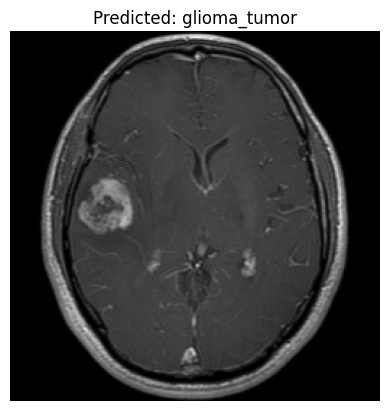

In [ ]:
img = image.load_img(img_path)

plt.imshow(img)
plt.title(f"Predicted: {label}")
plt.axis("off")
plt.show()

DEEPER CNN MODEL

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model2 = Sequential()


# Block 1
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

#  Block 2
model2.add(Conv2D(64, (3,3), activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

# Block 3
model2.add(Conv2D(128, (3,3), activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

# Block 4 (deeper than baseline)
model2.add(Conv2D(256, (3,3), activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

#  Fully Connected Layers
model2.add(Flatten())
model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.5))   # helps prevent overfitting
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.3))

# Output Layer (4 classes)
model2.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,861,188 (37.62 MB)

 Trainable params: 9,860,228 (37.61 MB)

 Non-trainable params: 960 (3.75 KB)

COMPILE

In [ ]:
from tensorflow.keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # Changed from 'categorical_crossentropy'
    metrics=['accuracy']
)

TRAIN

In [ ]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 274ms/step - accuracy: 0.4270 - loss: 2.0333 - val_accuracy: 0.4008 - val_loss: 1.3003
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5419 - loss: 1.1052 - val_accuracy: 0.4294 - val_loss: 1.1750
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.5924 - loss: 0.9759 - val_accuracy: 0.6176 - val_loss: 1.0071
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.6261 - loss: 0.8898 - val_accuracy: 0.6933 - val_loss: 0.8519
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.6721 - loss: 0.8102 - val_accuracy: 0.7464 - val_loss: 0.7036
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.7140 - loss: 0.7473 - val_accuracy: 0.7444 - val_loss: 0.6490
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.7518 - loss: 0.6296 - val_accuracy: 0.7791 - val_loss: 0.6007
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.7630 - loss: 0.5829 - val_accur

PLOT LOSS & ACCURACY

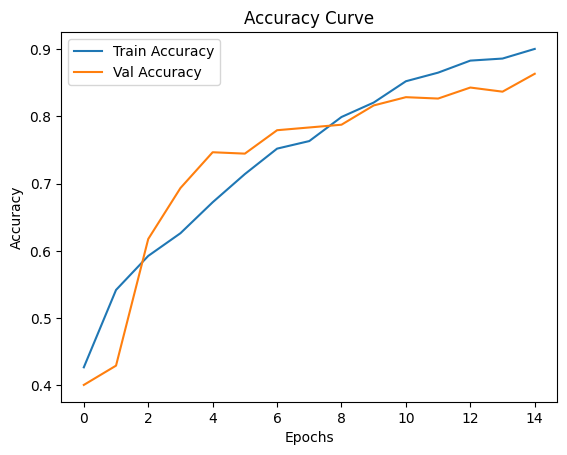

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

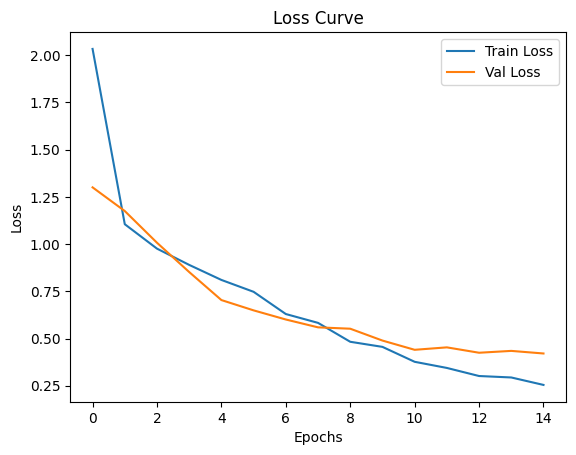

In [ ]:
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Compare Loss Curves (Baseline vs Deep Model)

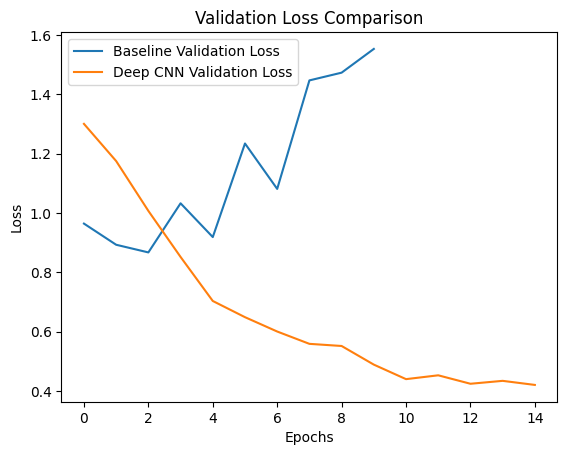

In [ ]:
plt.plot(history.history['val_loss'],  label='Baseline Validation Loss')
plt.plot(history2.history['val_loss'], label='Deep CNN Validation Loss')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

y_pred_deep = model2.predict(test_ds)
y_pred_deep_classes = np.argmax(y_pred_deep, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Accuracy:", accuracy_score(y_true, y_pred_deep_classes))
print(classification_report(y_true, y_pred_deep_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step
Accuracy: 0.8534621578099839
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       181
           1       0.76      0.81      0.79       183
           2       0.92      0.89      0.90        88
           3       0.93      0.94      0.94       169

    accuracy                           0.85       621
   macro avg       0.86      0.86      0.86       621
weighted avg       0.86      0.85      0.85       621



Confusion Matrix

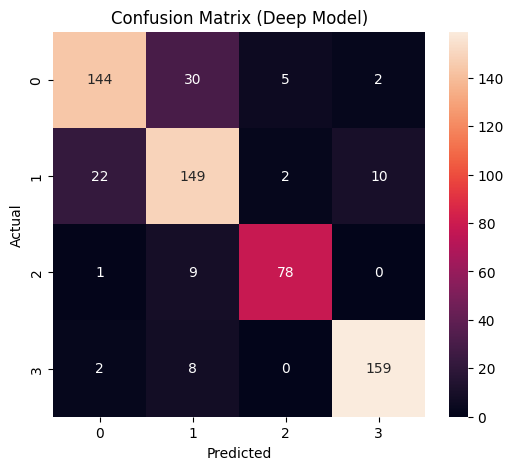

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_deep_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Deep Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SGD Optimizer Model

COMPILE

In [ ]:
model2.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy', # Changed to sparse_categorical_crossentropy
    metrics=['accuracy']
)

TRAIN

In [ ]:
history_sgd = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 233ms/step - accuracy: 0.8529 - loss: 0.4009 - val_accuracy: 0.4663 - val_loss: 1.3783
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.8350 - loss: 0.4418 - val_accuracy: 0.4847 - val_loss: 2.6218
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.8616 - loss: 0.3811 - val_accuracy: 0.7301 - val_loss: 0.7778
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.8754 - loss: 0.3435 - val_accuracy: 0.3497 - val_loss: 3.3135
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.8871 - loss: 0.2961 - val_accuracy: 0.6564 - val_loss: 1.4327
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.9025 - loss: 0.2550 - val_accuracy: 0.8548 - val_loss: 0.5572
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.9290 - loss: 0.1919 - val_accuracy: 0.8691 - val_loss: 0.4353
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9341 - loss: 0.1750 - val_accuracy: 

EVALUATION

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Predictions from SGD-trained model
y_pred_sgd = model2.predict(test_ds)
y_pred_sgd_classes = np.argmax(y_pred_sgd, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
# Removed: y_true = np.argmax(y_true, axis=1) as y_true already contains integer labels

# Accuracy
print("SGD Model Accuracy:", accuracy_score(y_true, y_pred_sgd_classes))

# Classification Report
print(classification_report(y_true, y_pred_sgd_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step
SGD Model Accuracy: 0.7906602254428341
              precision    recall  f1-score   support

           0       0.98      0.66      0.79       181
           1       0.62      0.93      0.74       183
           2       0.82      0.95      0.88        88
           3       0.97      0.69      0.81       169

    accuracy                           0.79       621
   macro avg       0.85      0.81      0.81       621
weighted avg       0.85      0.79      0.79       621



Adam vs SGD PLOT

ACCURACY

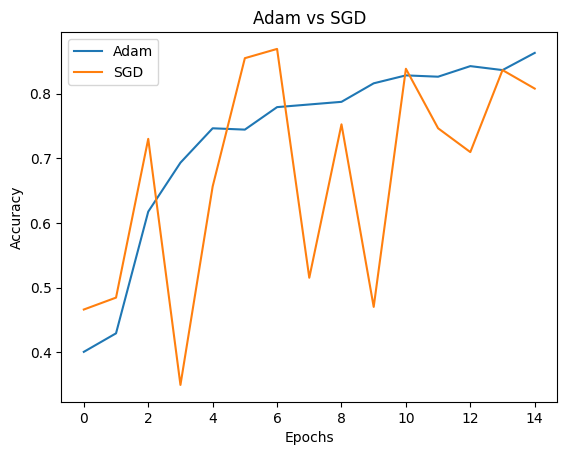

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.legend()
plt.title("Adam vs SGD")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

LOSS

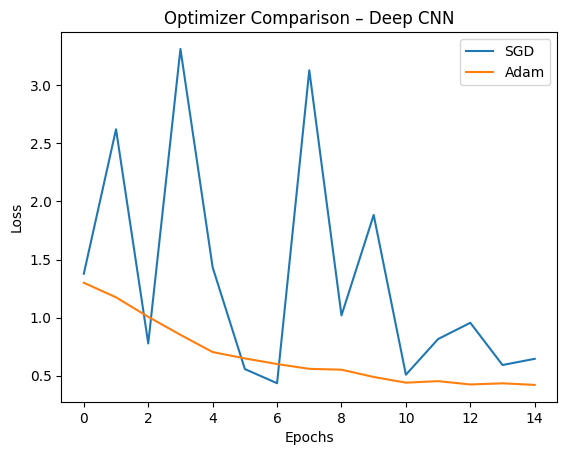

In [ ]:
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history2.history['val_loss'],    label='Adam')
plt.title("Optimizer Comparison – Deep CNN")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Prediction on Single Image

In [ ]:
label_deep, _ = predict_image(img_path, mdl=model2)
print("Deep CNN Predicted Class:", label_deep)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Deep CNN Predicted Class: normal


Transfer Learning – Loading Pretrained Model

Import VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

Load Pretrained VGG16 Model (ImageNet)

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

Freeze Base Model Layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

Add Custom Classification Head

In [ ]:
x = base_model.output
x = Flatten()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax')(x)

Build Final Model

In [ ]:
model_vgg = Model(inputs=base_model.input, outputs=output)

Model Summary

In [ ]:
model_vgg.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           51

 Total params: 21,170,884 (80.76 MB)

 Trainable params: 6,456,196 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Compile Model

In [ ]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Transfer Learning Model

In [ ]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 48s 475ms/step - accuracy: 0.5174 - loss: 12.7652 - val_accuracy: 0.7157 - val_loss: 1.1908
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 244ms/step - accuracy: 0.5245 - loss: 1.6882 - val_accuracy: 0.6564 - val_loss: 0.8557
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.5970 - loss: 1.2041 - val_accuracy: 0.7444 - val_loss: 0.9048
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - accuracy: 0.6425 - loss: 1.0894 - val_accuracy: 0.6810 - val_loss: 0.9319
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.6583 - loss: 1.0213 - val_accuracy: 0.7444 - val_loss: 0.7976
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.6537 - loss: 1.0242 - val_accuracy: 0.7689 - val_loss: 0.7501
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.6726 - loss: 0.9368 - val_accuracy: 0.7628 - val_loss: 0.7420
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 249ms/step - accuracy: 0.7007 - loss: 0.8709 - val_acc

In [ ]:
# Predictions
y_pred = model_vgg.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Metrics
print("Accuracy:", accuracy_score(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 605ms/step
Accuracy: 0.8115942028985508
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       181
           1       0.67      0.79      0.73       183
           2       1.00      0.62      0.77        88
           3       0.93      0.86      0.89       169

    accuracy                           0.81       621
   macro avg       0.85      0.79      0.81       621
weighted avg       0.83      0.81      0.81       621



Accuracy plot

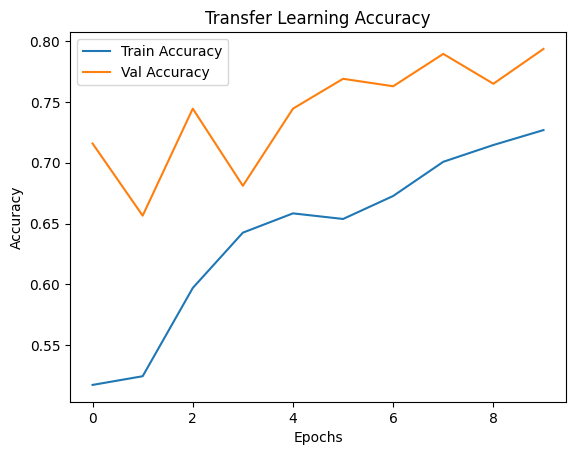

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Fine-Tuning (Unfreeze last layers)

In [ ]:
for layer in base_model.layers[-4:]:
    layer.trainable = True

Recompile (VERY IMPORTANT)

In [ ]:
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Fine-Tune Training

In [ ]:
history_finetune = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 361ms/step - accuracy: 0.7564 - loss: 0.6753 - val_accuracy: 0.8200 - val_loss: 0.6694
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 291ms/step - accuracy: 0.7880 - loss: 0.6073 - val_accuracy: 0.8323 - val_loss: 0.6709
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 308ms/step - accuracy: 0.7926 - loss: 0.5872 - val_accuracy: 0.8098 - val_loss: 0.6486
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 273ms/step - accuracy: 0.8034 - loss: 0.5397 - val_accuracy: 0.8303 - val_loss: 0.6045
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - accuracy: 0.8350 - loss: 0.4933 - val_accuracy: 0.8384 - val_loss: 0.5902
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 278ms/step - accuracy: 0.8345 - loss: 0.5034 - val_accuracy: 0.8282 - val_loss: 0.5896
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 293ms/step - accuracy: 0.8509 - loss: 0.4450 - val_accuracy: 0.8323 - val_loss: 0.5992
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 285ms/step - accuracy: 0.8570 - loss: 0.4075 - val_accu

Evaluate Model

In [ ]:
y_pred = model_vgg.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Accuracy:", accuracy_score(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step
Accuracy: 0.8727858293075684
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       181
           1       0.76      0.88      0.82       183
           2       0.97      0.84      0.90        88
           3       0.91      0.96      0.93       169

    accuracy                           0.87       621
   macro avg       0.89      0.87      0.88       621
weighted avg       0.88      0.87      0.87       621



PLOT GRAPH

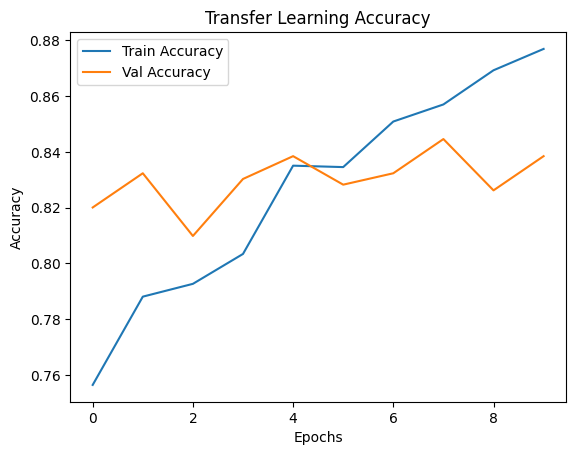

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

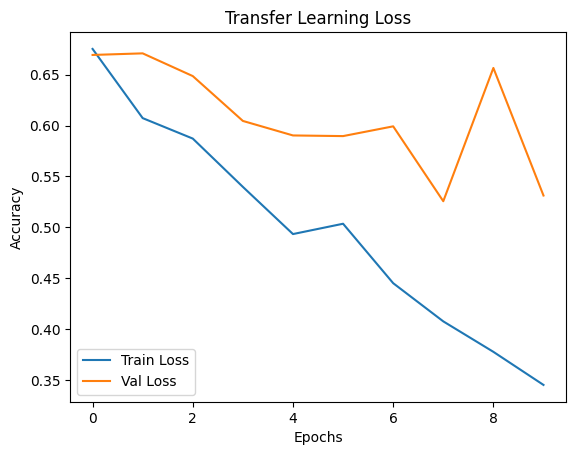

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Transfer Learning Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Confusion Matrix

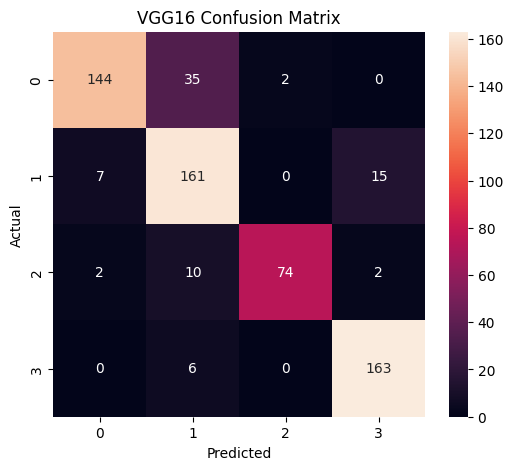

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()